In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")

In [3]:
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


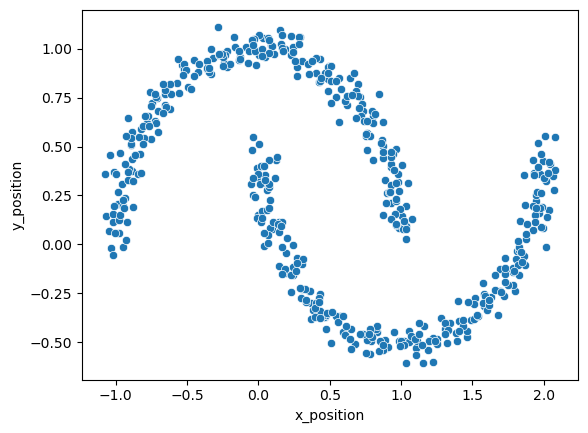

In [5]:
sns.scatterplot(data=df, x="x_position", y="y_position")
plt.show()

In [6]:
df = df.drop("true_cluster", axis=1)

In [7]:
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [10]:
X_scaled = scaler.fit_transform(df)

In [11]:
from sklearn.cluster import DBSCAN

In [12]:
dbscan = DBSCAN()

In [13]:
dbscan.fit(X_scaled)

DBSCAN()

In [14]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [15]:
X_scaled = pd.DataFrame(X_scaled, columns=["x_position", "y_position"])

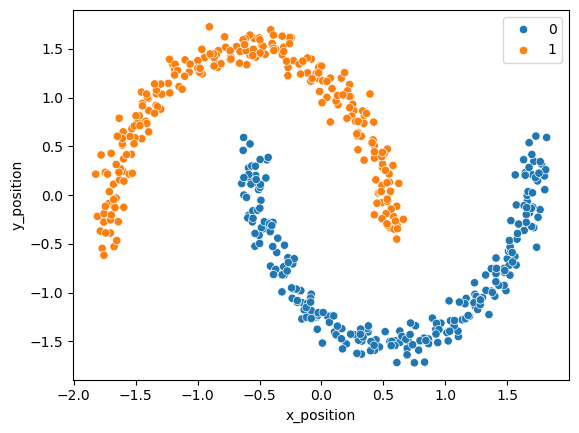

In [19]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=dbscan.labels_)
plt.show()

In [20]:
df = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")

In [21]:
df.columns

Index(['x_position', 'y_position', 'true_cluster'], dtype='object')

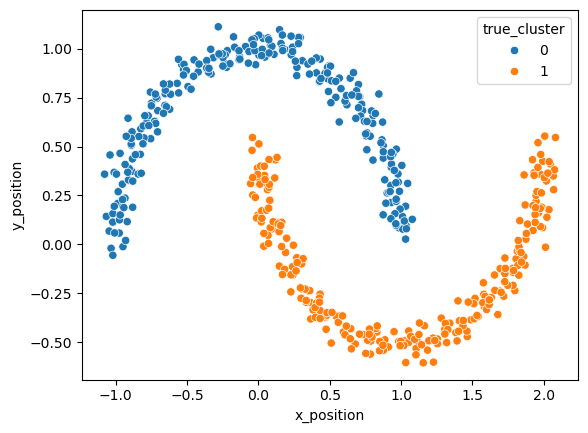

In [22]:
sns.scatterplot(data=df, x="x_position", y="y_position", hue="true_cluster")
plt.show()

In [23]:
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [4,5,6]

In [27]:
from sklearn.metrics import silhouette_score
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels=db.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, labels)
        results.append(
            {
                "eps":eps,
                "min_samples":min_samples,
                "Silhouette":silhouette,
                "n_clusters":len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhouette", ascending=False)
        

In [29]:
results_df

,eps,min_samples,Silhouette,n_clusters
4,0.2,5,0.389338,2
3,0.2,4,0.389338,2
14,0.5,6,0.389338,2
11,0.4,6,0.389338,2
5,0.2,6,0.389338,2
6,0.3,4,0.389338,2
8,0.3,6,0.389338,2
7,0.3,5,0.389338,2
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2


In [30]:
from sklearn.cluster import HDBSCAN

In [31]:
hdbscan=HDBSCAN()

In [32]:
hdbscan.fit(X_scaled)

HDBSCAN()

In [33]:
hdbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

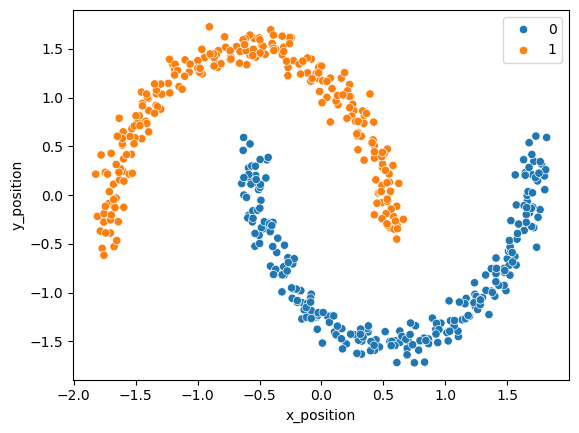

In [35]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=hdbscan.labels_)
plt.show()

In [36]:
min_cluster_size =[3,5,7,10]
min_samples=[None,3,5,7]
from sklearn.metrics import silhouette_score
results = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels=hdb.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, labels)
        results.append(
            {
                "min_cluster_size":min_cluster,
                "min_samples":min_samples,
                "Silhouette":silhouette,
                "n_clusters":len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhouette", ascending=False)
        

In [37]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters
3,3,"[None, 3, 5, 7]",0.389338,2
2,3,"[None, 3, 5, 7]",0.389338,2
5,5,"[None, 3, 5, 7]",0.389338,2
4,5,"[None, 3, 5, 7]",0.389338,2
6,5,"[None, 3, 5, 7]",0.389338,2
7,5,"[None, 3, 5, 7]",0.389338,2
9,7,"[None, 3, 5, 7]",0.389338,2
8,7,"[None, 3, 5, 7]",0.389338,2
12,10,"[None, 3, 5, 7]",0.389338,2
13,10,"[None, 3, 5, 7]",0.389338,2
